# ***Basic SetUp***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install ultralytics -q

In [ ]:
import torch
print(torch.cuda.get_device_name(0))
vram = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM: {vram:.1f} GB")
batch = 16 if vram > 14 else 8

# ***Yaml File***

In [ ]:
#yaml file

yaml_path  = """path: /content/drive/MyDrive/Seg_spliting/data_Black.yaml
train: train/images
val: val/images
test: test/images
nc: 1
names:
  0: biofouling
"""
with open(yaml_path, "w") as f:
    f.write(new_content)
print("تم ✓")

تم ✓


# ***Training***

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")

model.train(
    data="/content/drive/MyDrive/Seg_spliting/data_Black.yaml",
    epochs=100,
    imgsz=640,
    batch=32,
    patience=5,

    #Save on drive
    project="/content/drive/MyDrive/FINAL_GP2_SEG/Seg_spliting_RUNS",
    name="11SMALL_BASIC_32BATCH_BLACK",
    exist_ok=True
)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Seg_spliting/data_Black.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=11SMALL_BASIC_32BATCH_BLACK, nbs=64, nms=False, opset=None, optimize=False, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f63115be7b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
yaml_path="/content/drive/MyDrive/Seg_spliting/data_Black.yaml"

In [ ]:
#Validation
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/FINAL_GP2_SEG/Seg_spliting_RUNS/11SMALL_BASIC_32BATCH_BLACK/weights/best.pt")

val_results = model.val(
    data=yaml_path,
    split="val",
    imgsz=640,
    batch=32,
    save_json=True,
)

print(f"mAP50:    {val_results.seg.map50:.4f}")
print(f"mAP50-95: {val_results.seg.map:.4f}")
print(f"Precision: {val_results.seg.mp:.4f}")
print(f"Recall:    {val_results.seg.mr:.4f}")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 1.2±0.8 ms, read: 19.8±24.1 MB/s, size: 117.7 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1XTDS7czohk73PNkOgBdI7JcVHrK0a8A5/Seg_spliting/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 13.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 6.1s/it 24.5s
                   all        100       1704      0.938      0.898      0.922      0.704      0.936      0.897      0.919      0.544
Speed: 9.1ms preprocess, 22.4ms inference, 0.0ms loss, 10.7ms postprocess per image
Saving /content/runs/segment/val-2/predictions.json...
Results saved to /content/runs/segment/val-2
mAP50:    0.9189
mAP50-95: 0.5437
Precision: 0.9363
Recall: 

# ***Test***

In [ ]:
#Test
test_results = model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=32,
    save_json=True,
)

print(f"mAP50:    {test_results.seg.map50:.4f}")
print(f"mAP50-95: {test_results.seg.map:.4f}")
print(f"Precision: {test_results.seg.mp:.4f}")
print(f"Recall:    {test_results.seg.mr:.4f}")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 1.1±0.7 ms, read: 0.9±1.3 MB/s, size: 120.5 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1XTDS7czohk73PNkOgBdI7JcVHrK0a8A5/Seg_spliting/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 24.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 7.5s/it 30.1s
                   all        100       1941      0.924      0.781      0.786      0.573      0.907      0.768      0.764      0.422
Speed: 5.4ms preprocess, 15.9ms inference, 0.0ms loss, 8.3ms postprocess per image
Saving /content/runs/segment/val-3/predictions.json...
Results saved to /content/runs/segment/val-3
mAP50:    0.7640
mAP50-95: 0.4219
Precision: 0.9066
Recall:    0.7676


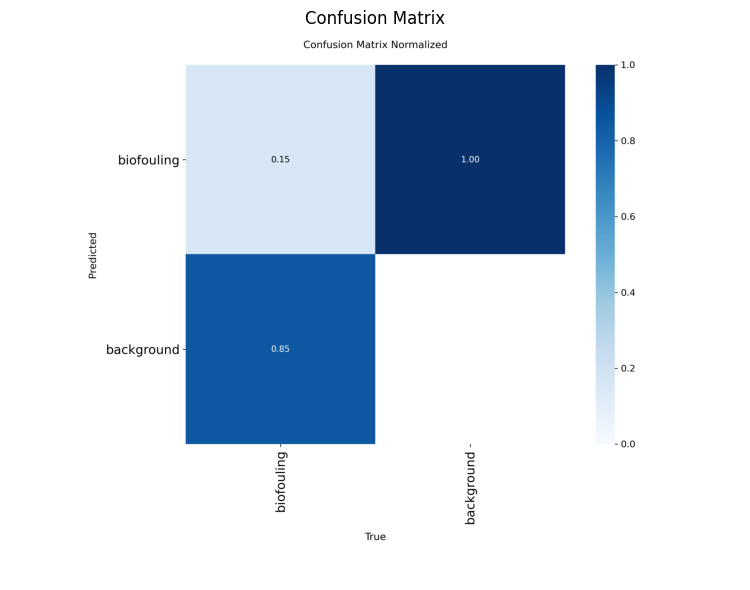

In [ ]:
#Confusion Matrix
import os
from PIL import Image
import matplotlib.pyplot as plt


run_dir = "/content/drive/MyDrive/biofouling_runs_11small_60iou/yolo11s_seg_v4_60iou"

cm_path = os.path.join(run_dir, "confusion_matrix_normalized.png")
if not os.path.exists(cm_path):
    cm_path = os.path.join(run_dir, "confusion_matrix.png")

img = Image.open(cm_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()